# 9.16 — 热噪声体素方差与柱坐标 Fisher

五个干涉配置；固定红移箱宽 $\Delta z=0.01$；保留原版基线、FoV、前景下限；
体素方差的总波数上限为 $0.363\,\mathrm{Mpc}^{-1}$；Fisher 上限保持 $0.535\,\mathrm{Mpc}^{-1}$。
不加入前景残差协方差 `Cfg`。前景模式截断仍按用户要求保留。

数值实现位于同目录的 `forecast_916.py` 与 `voxel_modes_916.py`。
修改配置后从头运行；旧 notebook 已备份在 `outputs_916/backups/`。


In [1]:
from pathlib import Path
import sys
from dataclasses import replace

RESEARCH_DIR = Path("/home/liuhk/research")
if str(RESEARCH_DIR) not in sys.path:
    sys.path.insert(0, str(RESEARCH_DIR))

from forecast_916 import Config, run_all, plot_results

SURVEYS = [
    "ska_mid1_interferom", "chime_icyl", "hirax_interferom",
    "tianlai_icyl", "meerkat_b1_interferom",
]
cfg = Config(
    delta_z=0.01,
    kmax=0.535,              # Fisher 总波数上限。
    voxel_kmax=0.363,        # 仅体素噪声方差的总波数上限。
    t_obs_hours=100000.0,
    boxsize_mpc_h=3000.0,
    grid_size=512,           # 定义体素边长；不额外施加FFT Nyquist截断。
    h_mock=0.6766,           # 模拟单位转换，独立于Fisher宇宙学的h。
    n_perp=96,
    n_parallel=64,
    n_z=2,
    run_fisher=True,         # 仅计算体素噪声时可改为False。
    output_dir=str(RESEARCH_DIR / "outputs_916"),
)
cfg


Config(delta_z=0.01, kmax=0.535, voxel_kmax=0.363, t_obs_hours=100000.0, boxsize_mpc_h=3000.0, grid_size=512, h_mock=0.6766, n_perp=96, n_parallel=64, n_z=2, pk_nodes=900, run_fisher=True, mock_file='/home/liuhk/research/mock_fisher_arr.joblib', mock_k_unit='h/Mpc', mock_redshifts=(0.511, 0.989, 1.501, 2.005, 2.501, 3.017), output_dir='/home/liuhk/research/outputs_916')

## 物理定义与积分归一化

体素边长 $\Delta=3000/(512h_{\rm mock})=8.66003\,\mathrm{Mpc}$，
窗口 $|W_{\rm pix}(\mathbf k)|^2=\prod_i\operatorname{sinc}^2(k_i\Delta/2)$，
其中 $\operatorname{sinc}(x)=\sin x/x$。

本次方差采用给定周期盒子的有限模式和：

$$\sigma_N^2(z)=\frac{1}{L_{\rm Mpc}^3}
\sum_{\mathbf k\in\mathcal D(z)}P_N(\mathbf k,z)|W_{\rm pix}(\mathbf k)|^2,
\qquad \mathbf k=\frac{2\pi}{L_{\rm Mpc}}\mathbf n.$$

`N=512` 定义体素平均宽度。方差仅保留 $k\le0.363\,\mathrm{Mpc}^{-1}$ 的球内模式。
当前盒长下最大轴向整数索引为256；代码仍不额外施加FFT立方体截断，
因此保留了正负Nyquist边界模式，并非严格的512³ FFT频率列表。
这一球形截断也会排除FFT立方体中总波数大于0.363的对角模式。CHIME/Tianlai的零密度到正密度线性插值
使连续 $\int dp/n(p)$ 存在边缘发散；有限盒模式和保留原版边界而不设置人为密度下限。
结果依赖明确指定的盒长，不能声称是该发散连续积分的收敛值。

Fisher在柱坐标中独立积分，令 $p=k_\perp,\ell=|k_\parallel|$：

$$F_{ij}=\int dz\,\frac{dV/dz}{4\pi^2}
\int_{\mathcal D(z),\ell>0}p\,dp\,d\ell\,
\frac{P_{,i}P_{,j}}{(P_{\rm HI}+P_N)^2+D_{\rm mock}}.$$

解析取 $D_{\rm mock}=0$；叠加mock时暂保留 $D_{\rm mock}=f_{\rm mock}P_{\rm HI}^2$，
模式数归一化按要求暂不修正。两种约束的比较使用相同mock覆盖域。
另存完整仪器域的解析结果。体素窗口不单独乘入Fisher权重。

原输出红移边界保留；实际频段外的箱输出NaN，部分覆盖箱按有效体积处理。
每个方差表值为该箱中配置的有限红移节点的体积加权平均。


In [2]:
# 运行并保存每个望远镜的CSV/joblib；CLASS参数模型在红移间复用。
results = run_all(cfg, SURVEYS)


[ska_mid1_interferom] bin 1/300: out_of_band


[ska_mid1_interferom] bin 11/300: partial_band


[ska_mid1_interferom] bin 21/300: ok


[ska_mid1_interferom] bin 31/300: ok


[ska_mid1_interferom] bin 41/300: ok


...

[meerkat_b1_interferom] bin 101/135: ok


[meerkat_b1_interferom] bin 111/135: ok


[meerkat_b1_interferom] bin 121/135: out_of_band


[meerkat_b1_interferom] bin 131/135: out_of_band


[meerkat_b1_interferom] bin 135/135: out_of_band


In [3]:
from IPython.display import display
import pandas as pd

variance_table = pd.concat([r["variance_table"] for r in results], ignore_index=True)
display(variance_table[["telescope", "z_low", "z_high", "z_effective", "status",
                        "coverage_fraction", "var_noise_mK2", "rms_noise_mK"]])
for result in results:
    print(result["telescope"])
    if cfg.run_fisher:
        # sigma_ana_common 与 sigma_ana_mock 使用完全相同的模式和红移域。
        display(result["constraints"])


,telescope,z_low,z_high,z_effective,status,coverage_fraction,var_noise_mK2,rms_noise_mK
0,ska_mid1_interferom,0.249968,0.259968,NaN,out_of_band,0.0,NaN,NaN
1,ska_mid1_interferom,0.259968,0.269968,NaN,out_of_band,0.0,NaN,NaN
2,ska_mid1_interferom,0.269968,0.279968,NaN,out_of_band,0.0,NaN,NaN
3,ska_mid1_interferom,0.279968,0.289968,NaN,out_of_band,0.0,NaN,NaN
4,ska_mid1_interferom,0.289968,0.299968,NaN,out_of_band,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...
983,meerkat_b1_interferom,1.596615,1.606615,NaN,out_of_band,0.0,NaN,NaN
984,meerkat_b1_interferom,1.606615,1.616615,NaN,out_of_band,0.0,NaN,NaN
985,meerkat_b1_interferom,1.616615,1.626615,NaN,out_of_band,0.0,NaN,NaN
986,meerkat_b1_interferom,1.626615,1.636615,NaN,out_of_band,0.0,NaN,NaN


ska_mid1_interferom


,sigma_ana_full,sigma_ana_full_cmb,sigma_ana_common,sigma_ana_common_cmb,sigma_ana_mock,sigma_ana_mock_cmb
param,,,,,,
lnA,0.018554,0.005020,0.019013,0.005076,0.019013,0.005076
Omega_m,0.011581,0.001785,0.012385,0.001884,0.012385,0.001884
omega_b,0.000642,0.000167,0.000649,0.000175,0.000649,0.000175
omega_cdm,0.001999,0.000830,0.002054,0.000863,0.002054,0.000863
n_s,0.008685,0.002024,0.008878,0.002031,0.008878,0.002031
w0,0.270891,0.009869,0.363619,0.010013,0.363619,0.010013
f_NL,37.959614,5.029089,40.422359,5.035482,40.422408,5.035482


chime_icyl


,sigma_ana_full,sigma_ana_full_cmb,sigma_ana_common,sigma_ana_common_cmb,sigma_ana_mock,sigma_ana_mock_cmb
param,,,,,,
lnA,0.003974,0.002147,0.003987,0.002151,0.003987,0.002151
Omega_m,0.001895,0.000449,0.001897,0.000450,0.001897,0.000450
omega_b,0.000103,0.000067,0.000103,0.000067,0.000103,0.000067
omega_cdm,0.000468,0.000277,0.000470,0.000278,0.000470,0.000278
n_s,0.002781,0.001446,0.002788,0.001447,0.002788,0.001447
w0,0.078174,0.006630,0.078327,0.006638,0.078329,0.006638
f_NL,10.064365,4.250735,10.128283,4.256082,10.128618,4.256124


...

,sigma_ana_full,sigma_ana_full_cmb,sigma_ana_common,sigma_ana_common_cmb,sigma_ana_mock,sigma_ana_mock_cmb
param,,,,,,
lnA,0.002935,0.001869,0.002983,0.001883,0.002983,0.001883
Omega_m,0.002239,0.000490,0.002247,0.000491,0.002247,0.000491
omega_b,0.000096,0.000071,0.000097,0.000071,0.000097,0.000071
omega_cdm,0.000382,0.000262,0.000390,0.000265,0.000390,0.000265
n_s,0.002293,0.001327,0.002351,0.001347,0.002351,0.001347
w0,0.081553,0.006575,0.082094,0.006630,0.082097,0.006630
f_NL,8.684519,4.006165,8.809879,4.020389,8.810119,4.020430


tianlai_icyl


,sigma_ana_full,sigma_ana_full_cmb,sigma_ana_common,sigma_ana_common_cmb,sigma_ana_mock,sigma_ana_mock_cmb
param,,,,,,
lnA,0.005637,0.002847,0.005692,0.002875,0.005692,0.002875
Omega_m,0.001318,0.000600,0.001344,0.000606,0.001344,0.000606
omega_b,0.000157,0.000068,0.000158,0.000069,0.000158,0.000069
omega_cdm,0.000539,0.000355,0.000549,0.000359,0.000549,0.000359
n_s,0.002052,0.001135,0.002135,0.001165,0.002136,0.001165
w0,0.056926,0.005608,0.059413,0.005738,0.059420,0.005738
f_NL,26.619764,4.927653,27.198647,4.929570,27.200973,4.929588


meerkat_b1_interferom


,sigma_ana_full,sigma_ana_full_cmb,sigma_ana_common,sigma_ana_common_cmb,sigma_ana_mock,sigma_ana_mock_cmb
param,,,,,,
lnA,0.064644,0.008533,0.067028,0.008548,0.067028,0.008548
Omega_m,0.030395,0.003275,0.032842,0.003391,0.032842,0.003391
omega_b,0.001953,0.000265,0.001996,0.000274,0.001996,0.000274
omega_cdm,0.008142,0.001485,0.008552,0.001529,0.008552,0.001529
n_s,0.052473,0.002104,0.058156,0.002105,0.058156,0.002105
w0,0.991547,0.010575,1.292439,0.010714,1.292442,0.010714
f_NL,426.194086,5.099245,458.757262,5.099298,458.758796,5.099298


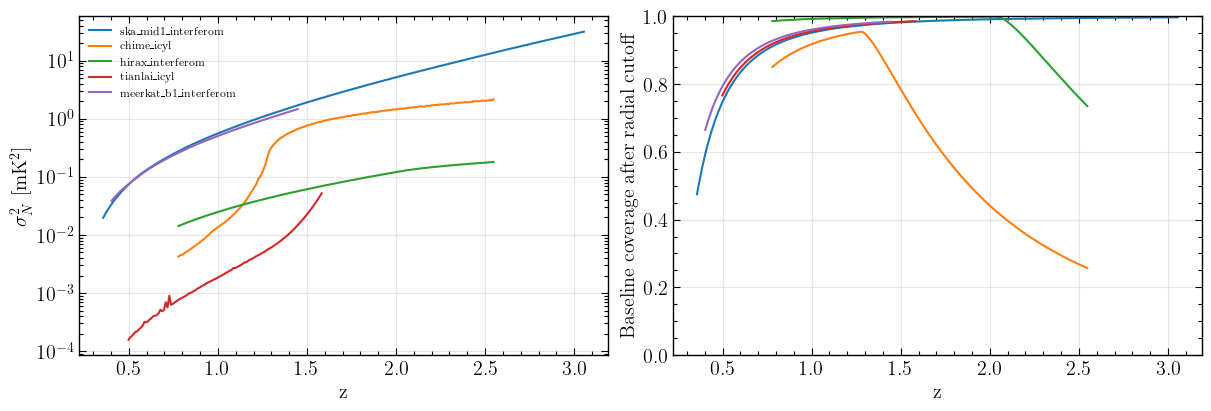

In [4]:
fig = plot_results(results, cfg.output_dir)


## 输出说明

- `voxel_noise_<survey>.csv/.joblib`：热噪声体素方差、RMS、频段覆盖与基线模型说明。
- `voxel_noise_all_surveys.csv`：五个配置合表。
- `constraints_<survey>.csv`：完整域解析、共同域解析、共同域解析加mock，以及各自加CMB的约束。
- `fisher_<survey>.joblib`：Fisher矩阵、参数顺序和元数据。
- `run_config.json`：本次配置。`validation.json`与`implementation_notes.md`记录验证和物理限制。

HIRAX缺少基线文件，继续采用6–200 m均匀基线模型。mock使用原产品的实际红移标签，
波数单位由`mock_k_unit`明确配置；不做越界填零或端点红移外推。
